# Cross-species directional transferability of chemical-gene perturbations

A curated chemical-gene effect observed in rodents: does its **direction** hold in humans, using **independent** evidence? And when it fails, is that biology (species) or noise (irreproducibility)?

This notebook is a narrative walkthrough. The heavy lifting lives in the `aimX_*.py` modules; run `python run_all.py` first to populate `derived/`, `tables/`, and `figures/`.

In [1]:
import pandas as pd, numpy as np
from analysis_core import Config, wilson_ci, cluster_bootstrap_mean
cfg = Config.default()
keys = pd.read_parquet(cfg.derived / 'effect_keys.parquet')
print('effect keys:', f'{len(keys):,}')
both = keys[keys['in_human'] & keys['in_rodent']]
print('seen in both species:', f'{len(both):,}')
print('PMID-disjoint share:', f"{both['pmid_disjoint_hr'].mean()*100:.1f}%")

effect keys: 1,165,406
seen in both species: 61,439
PMID-disjoint share: 90.1%


## 1. The co-curation trap

Naive agreement is inflated because human and rodent facts are often curated from the same paper. Compare agreement on shared-PMID pairs vs independent (disjoint) pairs.

In [2]:
def agree_rate(df):
    s = df[(df['h_cons'] != 0) & (df['rod_cons'] != 0)]
    k = int((s['h_cons'] == s['rod_cons']).sum()); n = len(s)
    p, lo, hi = wilson_ci(k, n)
    return n, p, lo, hi

disjoint = both[both['pmid_disjoint_hr']]
shared = both[~both['pmid_disjoint_hr']]
for name, d in [('independent (PRIMARY)', disjoint), ('shared-PMID', shared)]:
    n, p, lo, hi = agree_rate(d)
    print(f'{name:22s} n={n:6,}  agree={p*100:5.1f}%  ({lo*100:.1f}-{hi*100:.1f})')

independent (PRIMARY)  n=40,779  agree= 62.0%  (61.5-62.5)
shared-PMID            n= 4,778  agree= 89.2%  (88.3-90.1)


## 2. Is the divergence human-specific?

Mouse vs rat is a same-clade reproducibility ceiling. If human-vs-rodent disagreement is barely above mouse-vs-rat, phylogeny is not the driver.

In [3]:
hsd = pd.read_csv(cfg.tables / 'A2_human_specific_divergence.csv').iloc[0]
print(f"disagree(human,rodent) = {hsd['disagree_human_rodent']*100:.1f}%")
print(f"disagree(mouse,rat)    = {hsd['disagree_mouse_rat']*100:.1f}%")
print(f"HUMAN-SPECIFIC = {hsd['human_specific_divergence']*100:.1f} pts "
      f"(95% CI {hsd['hsd_boot_lo']*100:.1f} to {hsd['hsd_boot_hi']*100:.1f})")

disagree(human,rodent) = 38.0%
disagree(mouse,rat)    = 33.8%
HUMAN-SPECIFIC = 4.2 pts (95% CI -1.1 to 10.9)


## 3. Where transfer lives: mechanism, depth, and the pair itself

In [4]:
print('By molecular aspect:')
display(pd.read_csv(cfg.tables / 'A1_by_aspect.csv')[['stratum','n','p_agree','boot_lo','boot_hi']])
print('\nBy evidence depth:')
display(pd.read_csv(cfg.tables / 'A1_by_depth.csv')[['stratum','n','p_agree','boot_lo','boot_hi']])
print('\nVariance components (ICC):')
display(pd.read_csv(cfg.tables / 'A2_variance_components_icc.csv'))

By molecular aspect:


,stratum,n,p_agree,boot_lo,boot_hi
0,expression,36986,0.607987,0.583074,0.636414
1,activity,1106,0.893309,0.872026,0.912290
2,methylation,1102,0.419238,0.370649,0.644306
3,phosphorylation,744,0.814516,0.775292,0.850078
4,secretion,286,0.856643,0.810783,0.906046
5,cleavage,182,0.967033,0.941512,0.989305
6,response to substance,144,0.750000,0.672956,0.818909
7,metabolic processing,55,0.981818,0.942308,1.000000
8,abundance,53,0.849057,0.731684,0.953864
9,uptake,44,0.954545,0.890859,1.000000



By evidence depth:


,stratum,n,p_agree,boot_lo,boot_hi
0,min_pmids=1,38135,0.606897,0.575991,0.637183
1,min_pmids=2,1980,0.765152,0.701038,0.849360
2,min_pmids=3,374,0.906417,0.857143,0.968026
3,min_pmids=4,135,0.955556,0.926174,0.984000
4,min_pmids=5,60,1.000000,1.000000,1.000000
5,min_pmids=6,95,1.000000,1.000000,1.000000



Variance components (ICC):


,factor,n_groups,icc,var_between,var_within
0,chemical,1477,0.045514,0.010736,0.225148
1,gene,11949,0.068064,0.016037,0.219581
2,aspect,17,0.117212,0.030571,0.230247
3,chem_gene_pair,40200,0.441672,0.104063,0.131549
4,chem_class,7,0.005372,0.001268,0.234704


## 4. Predicting transfer for unseen chemicals

Grouped CV by chemical (every test chemical is unseen). The point is not a high AUC; it is that generic metadata carries little signal, which is itself the result.

In [5]:
display(pd.read_csv(cfg.tables / 'A3_cv_performance.csv'))
display(pd.read_csv(cfg.tables / 'A3_permutation_importance.csv'))

,model,auc_mean,auc_sd,ap_mean,brier_mean
0,logistic,0.561708,0.013584,0.712178,0.230179
1,gbm,0.582626,0.024748,0.725078,0.230829
2,baseline_prevalence,0.500000,0.000000,0.619976,0.235606


,feature,auc_drop
0,rodent_direction,0.055894
1,log_gene_promiscuity,0.037103
2,aspect,0.021145
3,log_chem_promiscuity,0.015875
4,rod_pmids_f,0.013275
5,rod_support,0.000026
6,log_pathway_deg,-0.000916
7,chem_class,-0.008945


## 5. External anchor: does sequence conservation explain transfer?

Everything above is internal to CTD curation. Aim 4 adds a pre-registered axis from *outside* CTD: Ensembl human-to-rodent protein percent identity and 1:1 orthology (with NCBI orthologs as a second anchor). If cross-species transfer were driven by molecular similarity, chemical effects on highly conserved genes should transfer more often than effects on divergent genes. They do not: agreement is flat across the full identity range, and conservation adds nothing to the predictor. This makes the failure genuinely biological (context-lability), not an artifact of comparing dissimilar proteins.

In [6]:
byq = pd.read_csv(cfg.tables / 'A4_agreement_by_conservation.csv')
trend = pd.read_csv(cfg.tables / 'A4_conservation_trend.csv').iloc[0]
inc = pd.read_csv(cfg.tables / 'A4_incremental_cv.csv')
print('Directional agreement by human-rodent protein-identity quartile:')
for _, r in byq.iterrows():
    print(f"  Q{int(r.cons_quartile)}  median {r.perc_id_median:4.1f}% id  n={int(r.n):,}  agree {r.p_agree*100:4.1f}%  ({r.boot_lo*100:.1f}-{r.boot_hi*100:.1f})")
print(f"\nTrend (cluster-robust logistic): OR {trend.or_per_10pct:.2f} per +10 pts identity "
      f"({trend.or_lo_per_10pct:.2f}-{trend.or_hi_per_10pct:.2f}), p={trend.p_value:.2f}")
print('\nAdding conservation to the CTD-internal predictor (grouped-by-chemical CV):')
for _, r in inc.iterrows():
    print(f"  {r.model:28s} AUC {r.auc_mean:.3f}   Brier {r.brier_mean:.3f}")

Directional agreement by human-rodent protein-identity quartile:
  Q1  median 70.4% id  n=9,987  agree 63.0%  (60.6-66.2)
  Q2  median 83.4% id  n=9,987  agree 61.8%  (58.5-65.2)
  Q3  median 90.5% id  n=9,976  agree 62.9%  (59.9-66.1)
  Q4  median 96.7% id  n=9,983  agree 60.5%  (56.5-64.4)

Trend (cluster-robust logistic): OR 0.97 per +10 pts identity (0.94-1.00), p=0.07

Adding conservation to the CTD-internal predictor (grouped-by-chemical CV):
  ctd_internal                 AUC 0.574   Brier 0.234
  ctd_internal+conservation    AUC 0.576   Brier 0.232
  delta(full-base)             AUC 0.002   Brier -0.002


## 6. Deliverable: hard cross-species conflicts

Independently-supported, opposite-direction pairs: candidate true species divergences or curation errors worth manual review.

In [7]:
cat = pd.read_csv(cfg.tables / 'A2_conflict_catalog.csv')
print('strong conflicts:', len(cat))
display(cat.head(25))

strong conflicts: 110


,chem_name,gene_symbol,aspect,h_cons,rod_cons,h_inc,h_dec,rod_inc,rod_dec,h_pmids,rod_pmids,chem_class
0,bisphenol A,RPL5,expression,-1,1,0,2,2,0,4,5,organic_pollutants
1,Paraquat,GCLC,expression,-1,1,0,2,4,0,2,7,heterocyclic_organic
2,Tetrachlorodibenzodioxin,ALPL,expression,1,-1,2,0,0,2,2,7,other
3,Tetrachlorodibenzodioxin,IL33,expression,1,-1,2,0,0,2,2,7,other
4,bisphenol A,ARL3,expression,1,-1,2,0,0,2,2,6,organic_pollutants
5,bisphenol A,RPL22L1,expression,-1,1,0,2,2,0,3,5,organic_pollutants
6,bisphenol A,RPL9,expression,-1,1,0,2,2,0,2,6,organic_pollutants
7,Resveratrol,IGF1R,expression,-1,1,0,2,3,0,4,4,organic_pollutants
8,Silicon Dioxide,LCN2,expression,-1,1,0,2,3,0,2,6,other
9,bisphenol A,RPL13A,expression,-1,1,0,2,3,0,2,5,organic_pollutants


## Figures

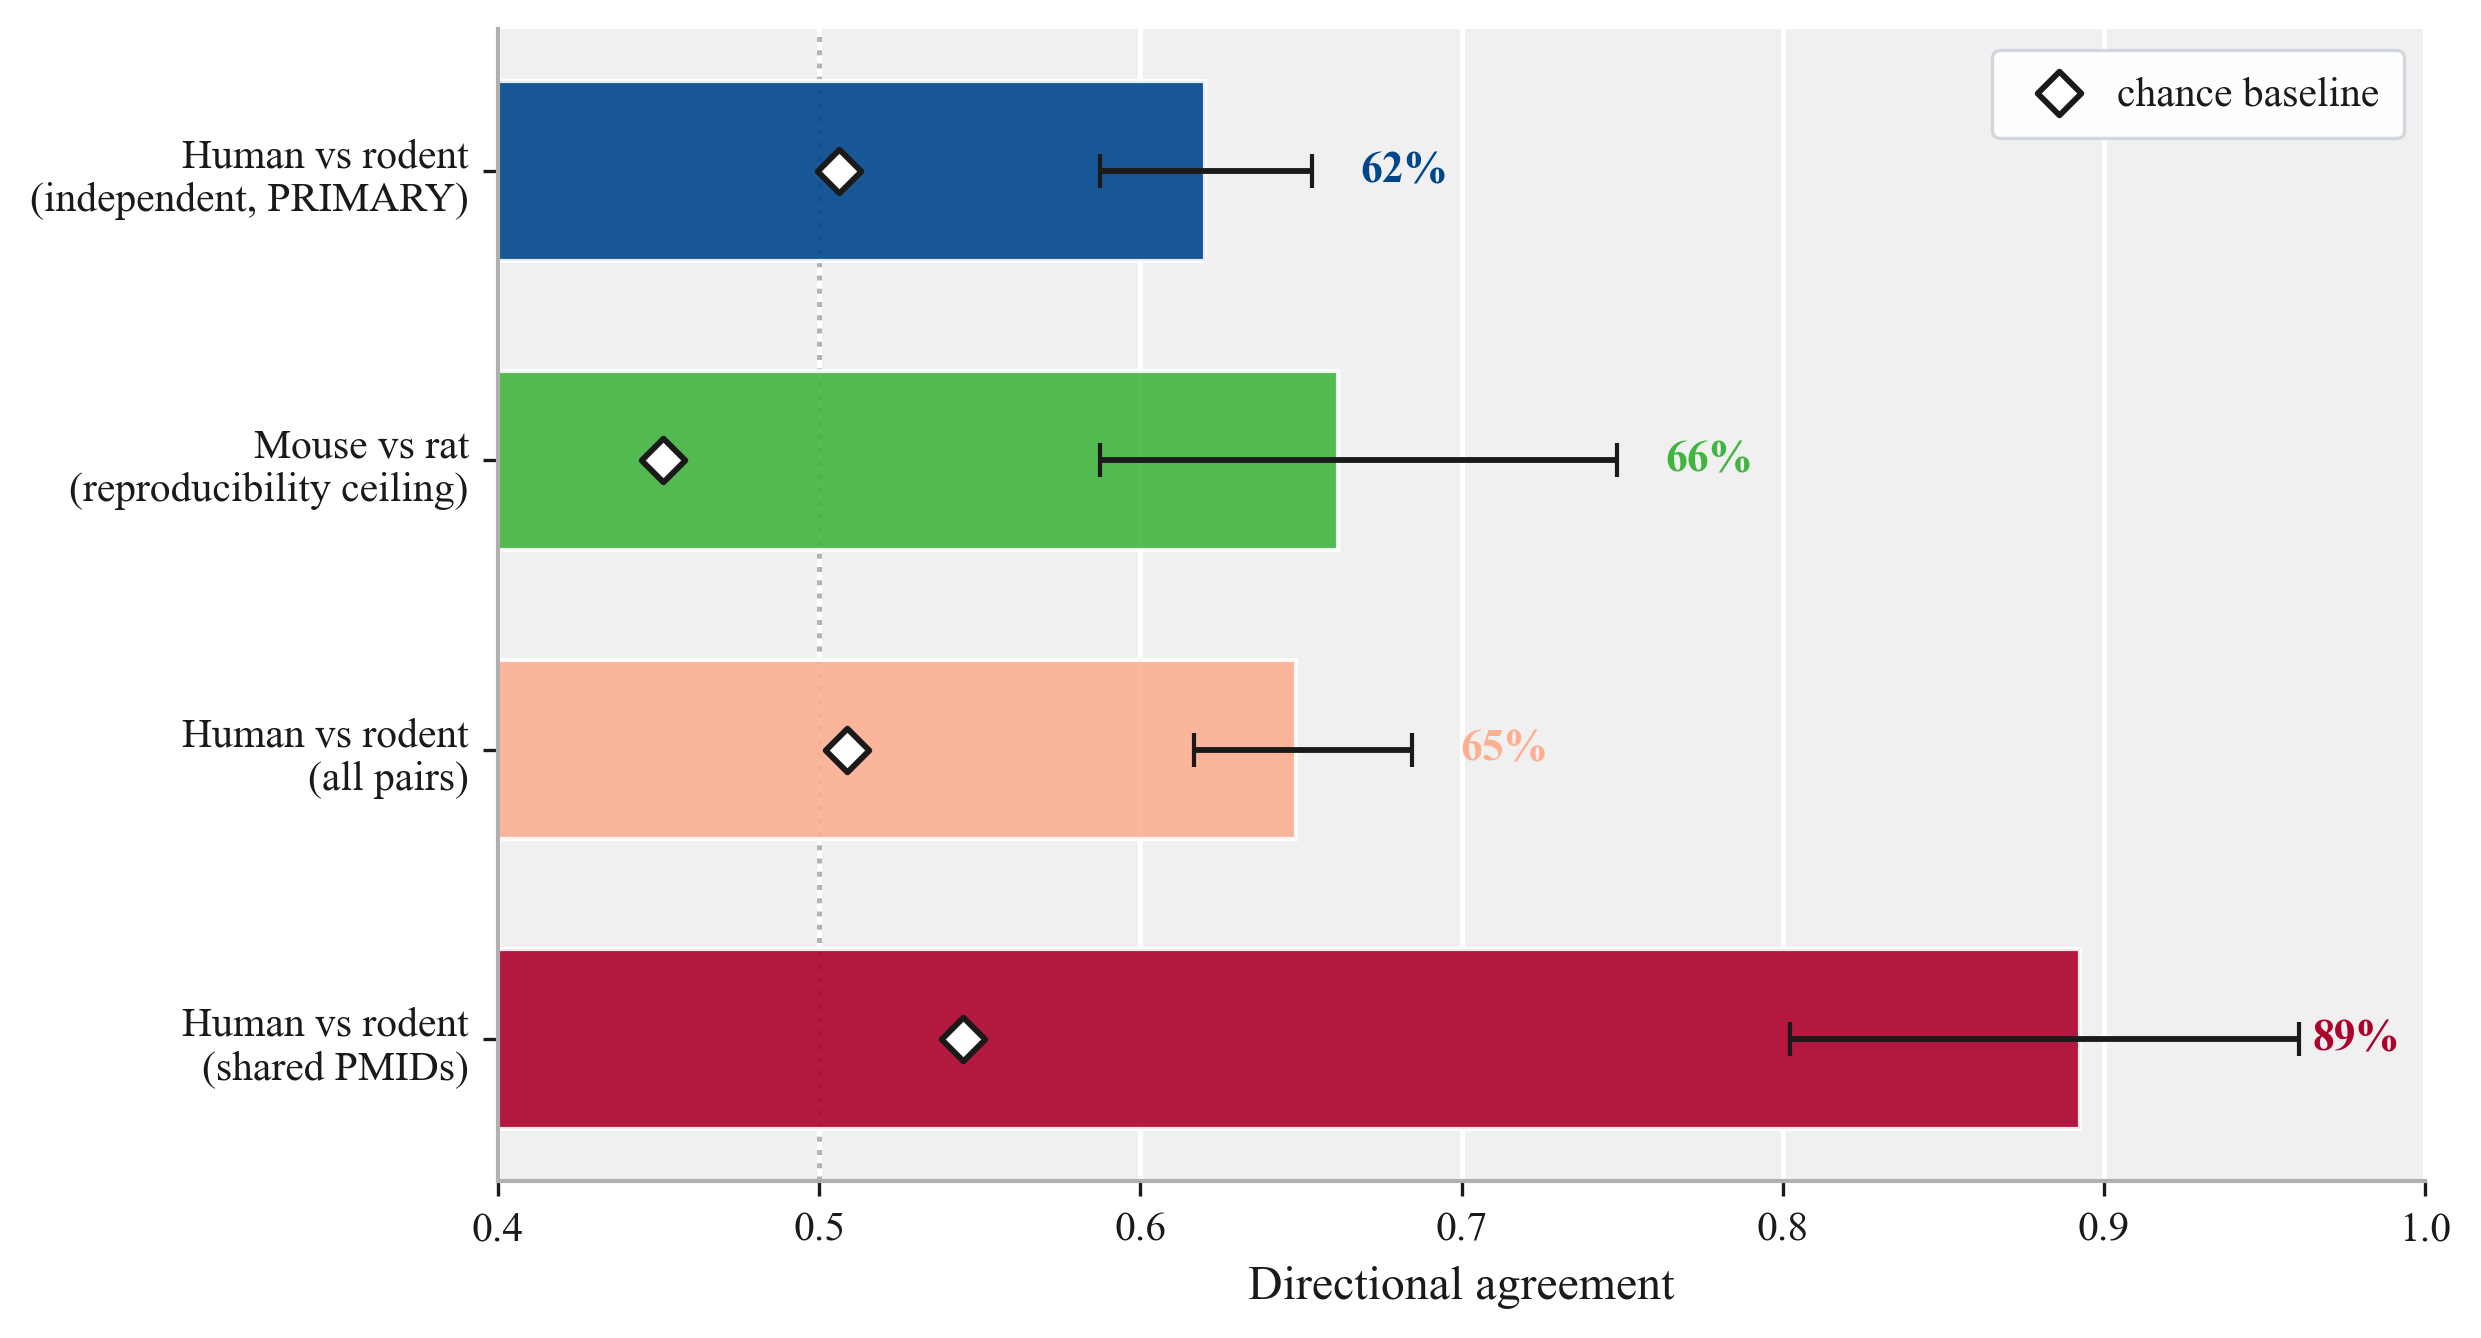

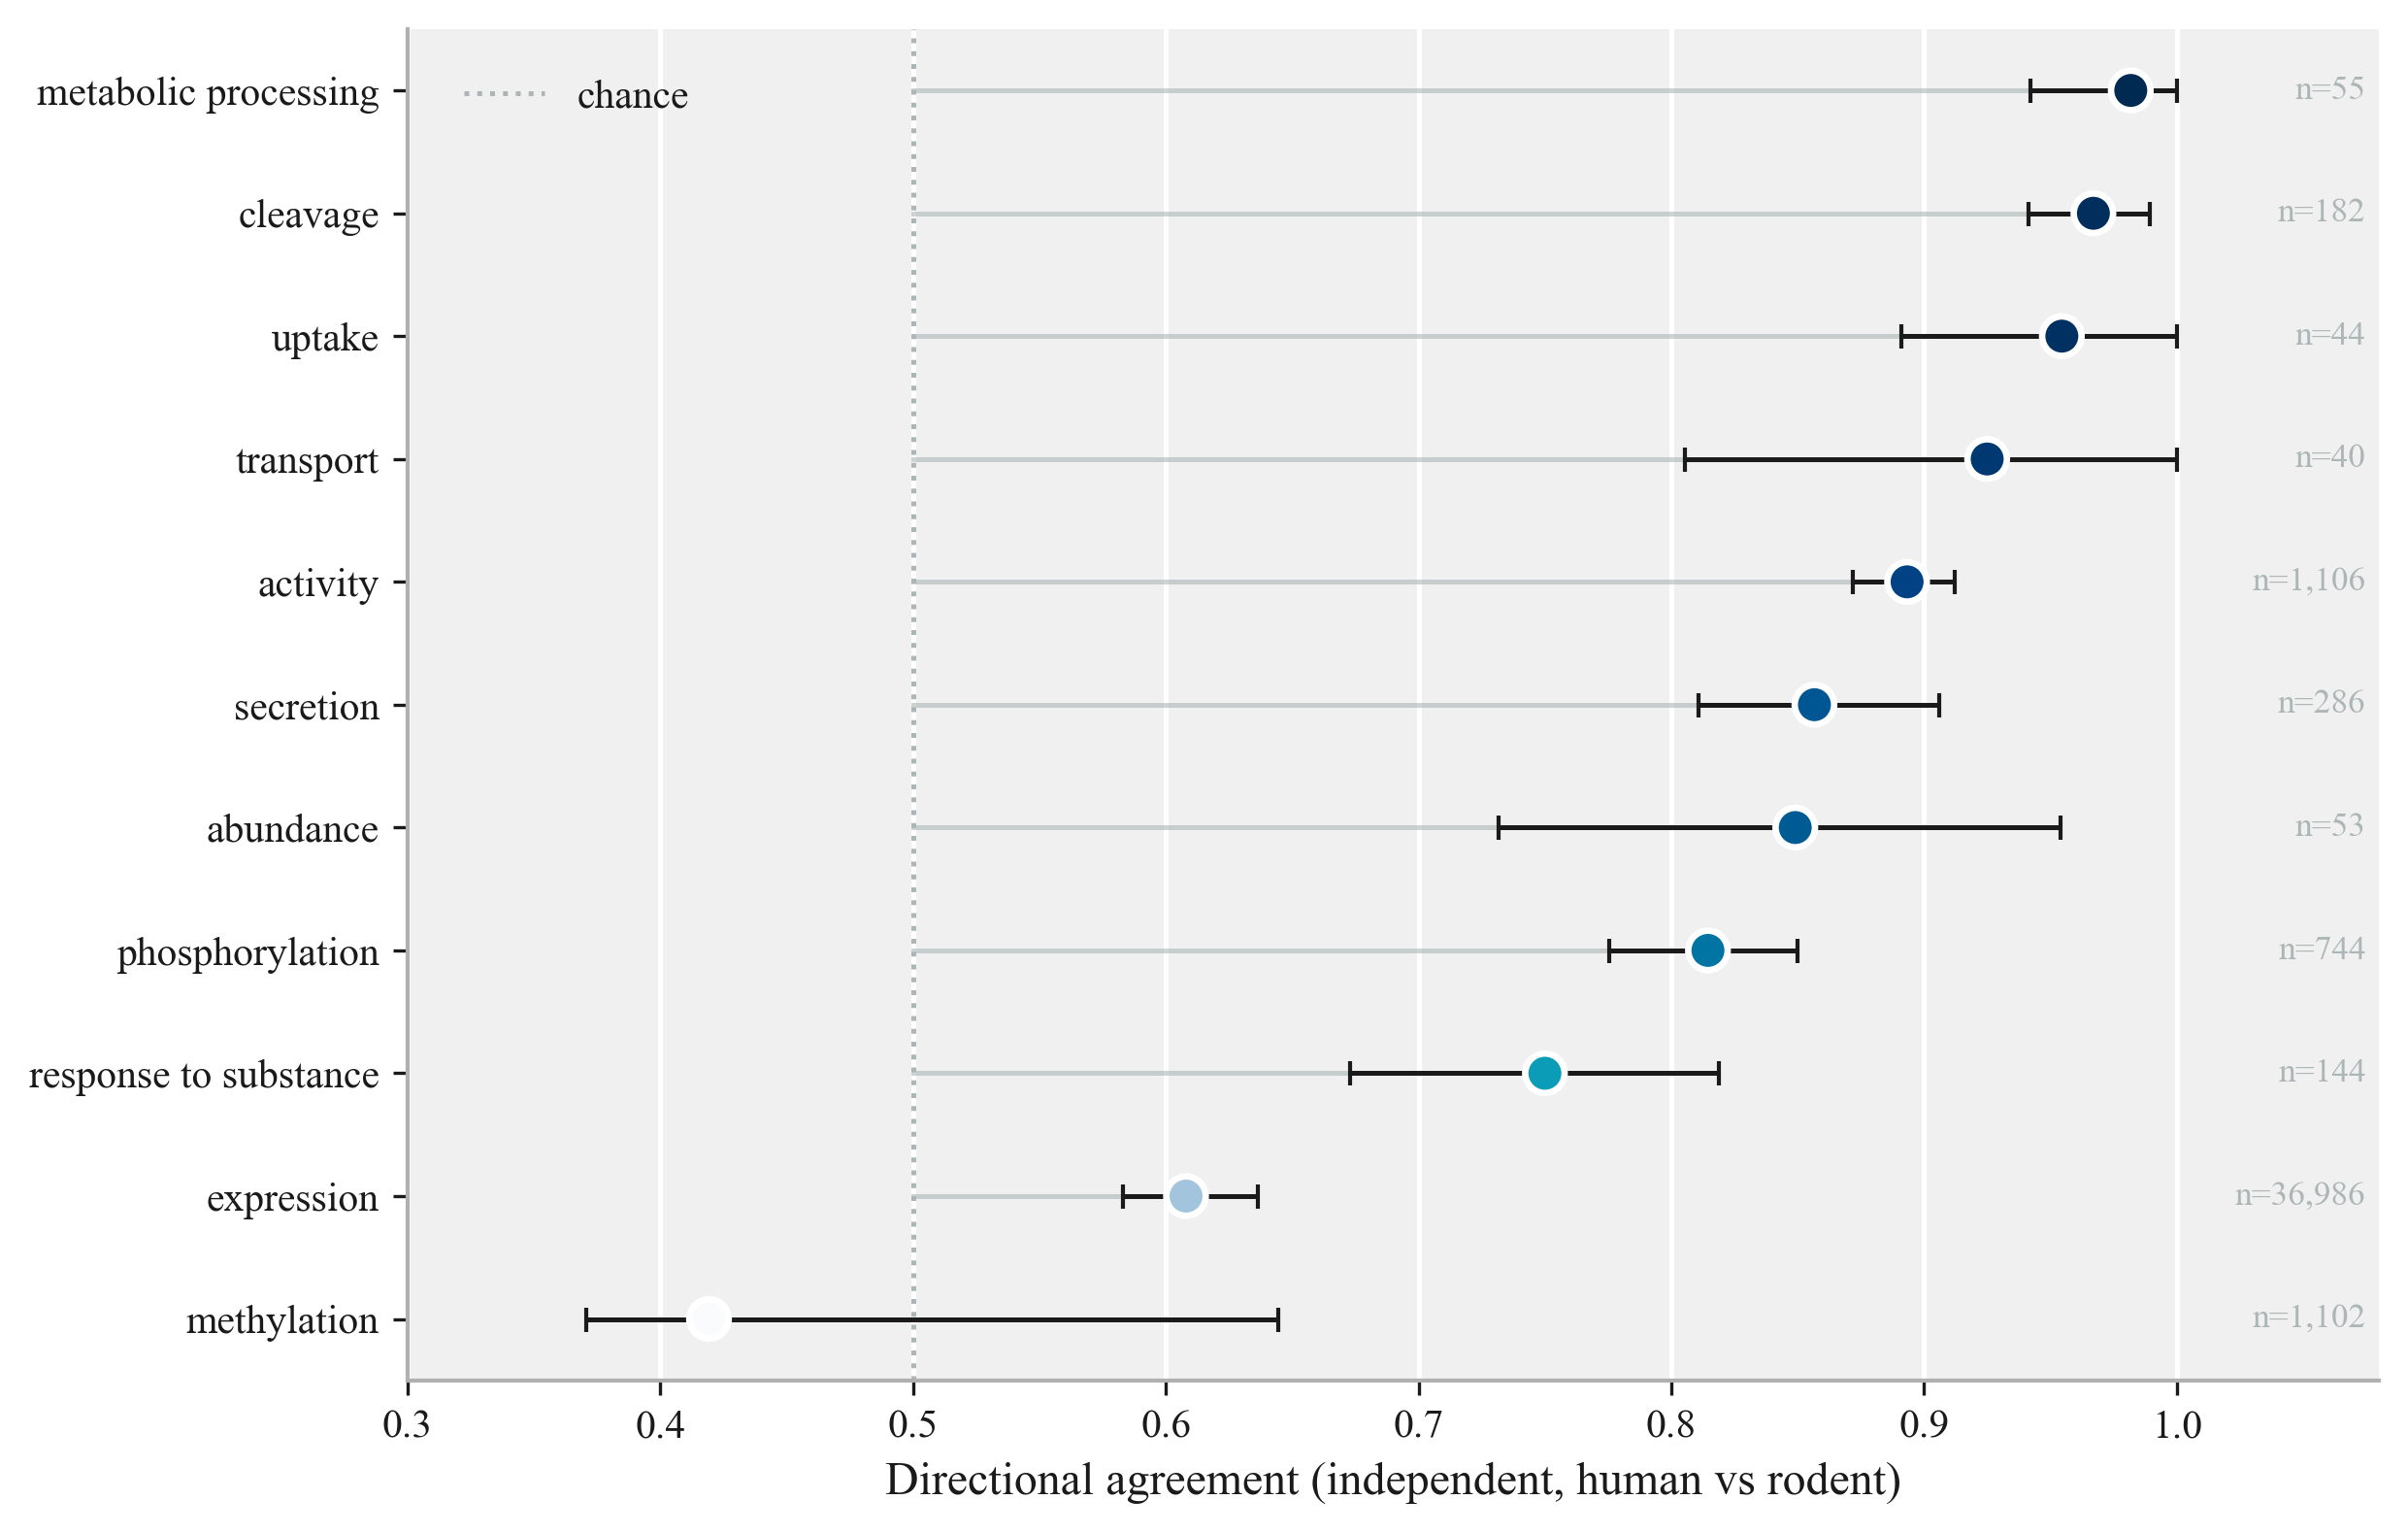

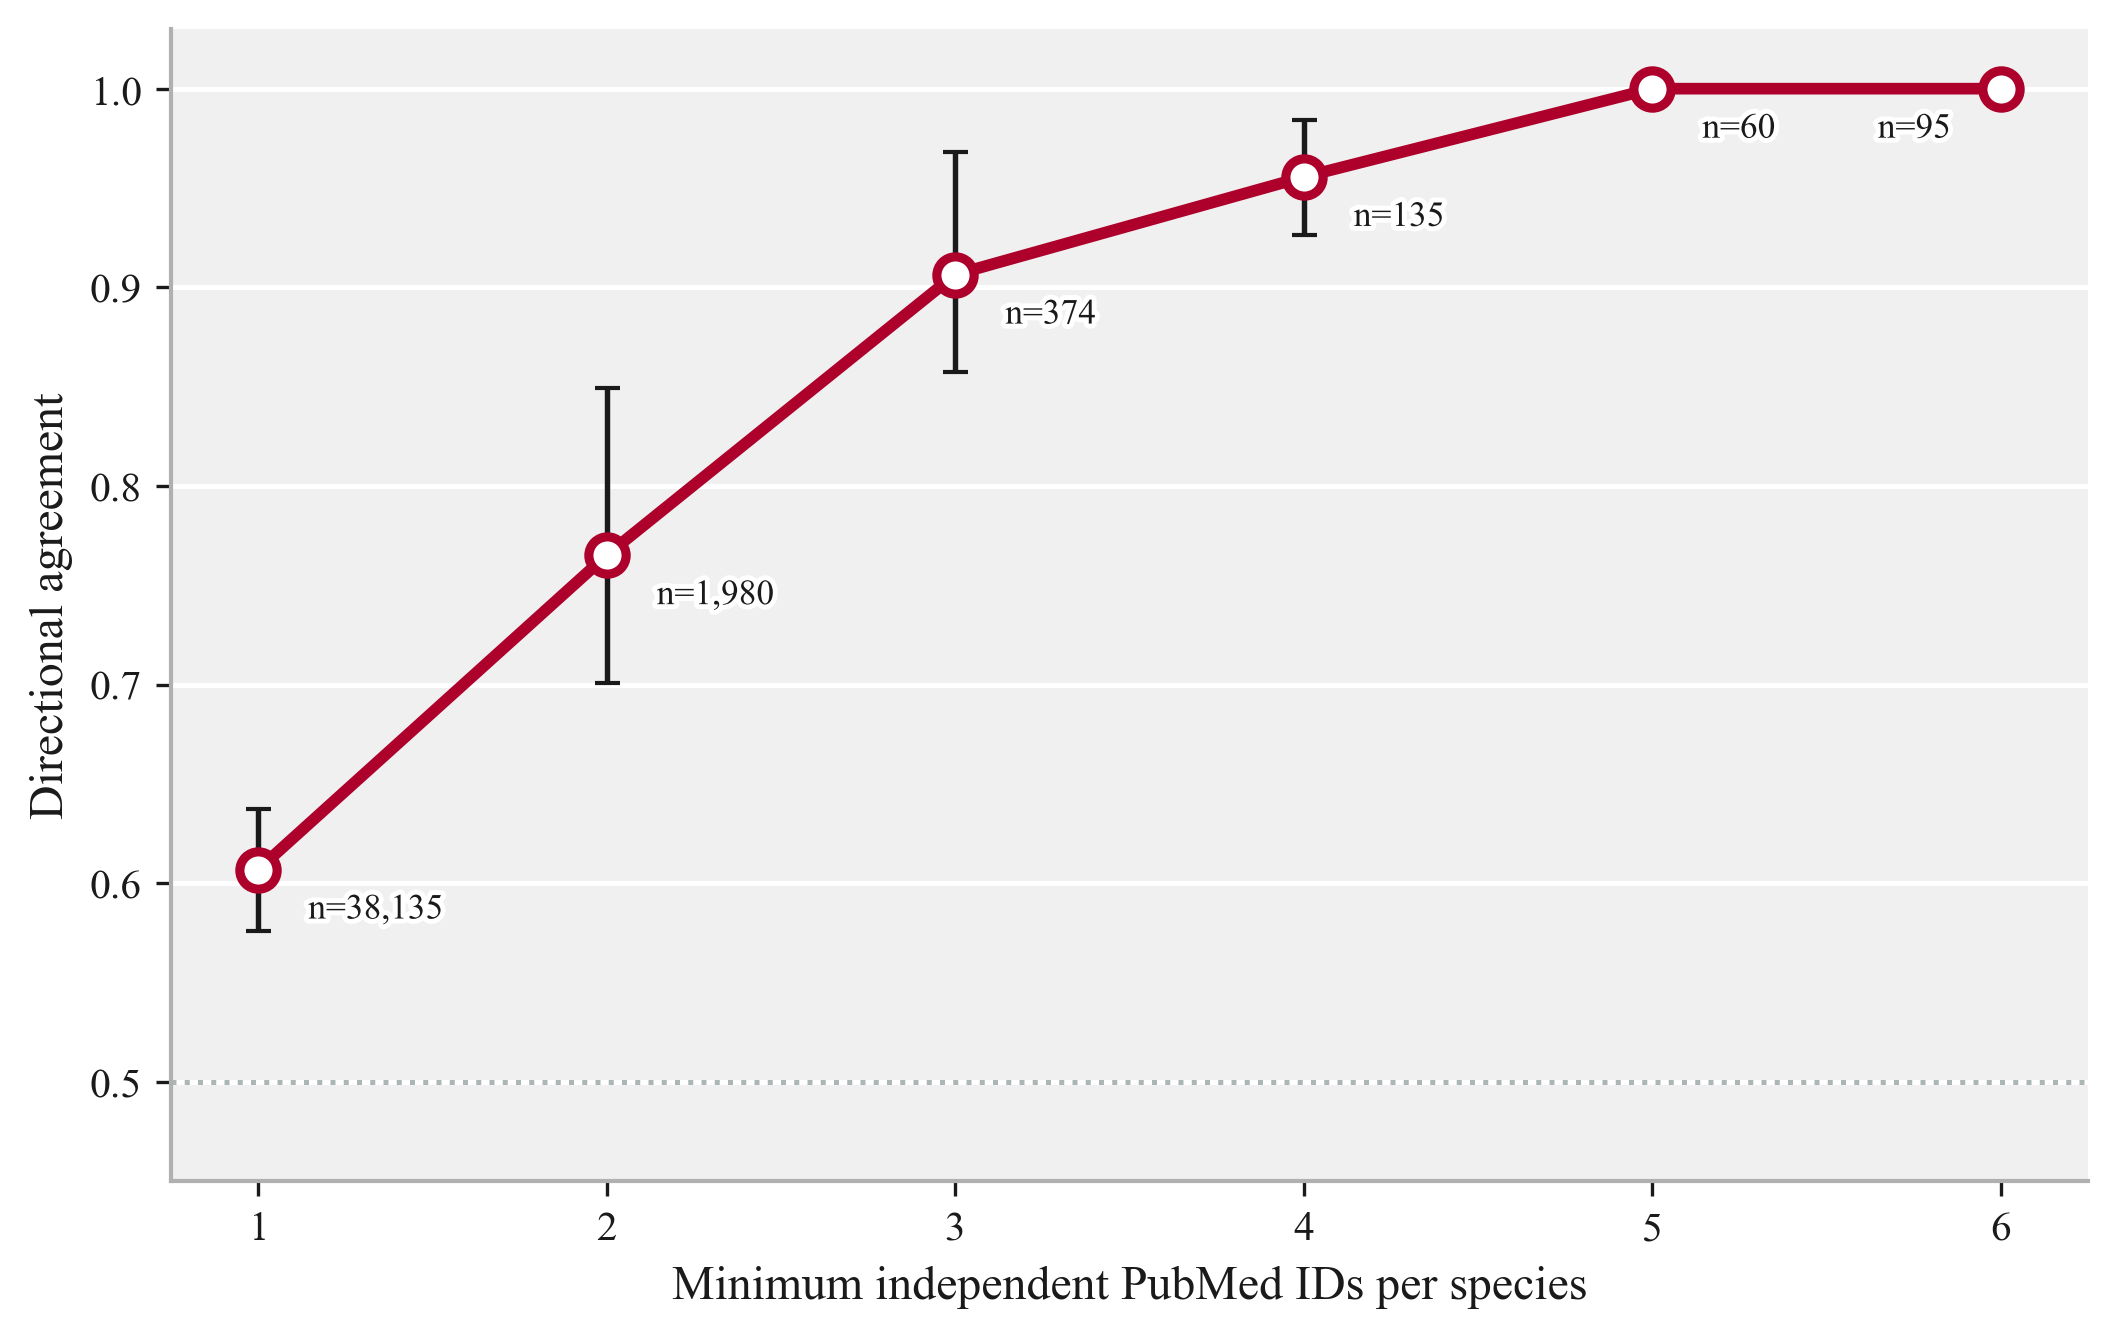

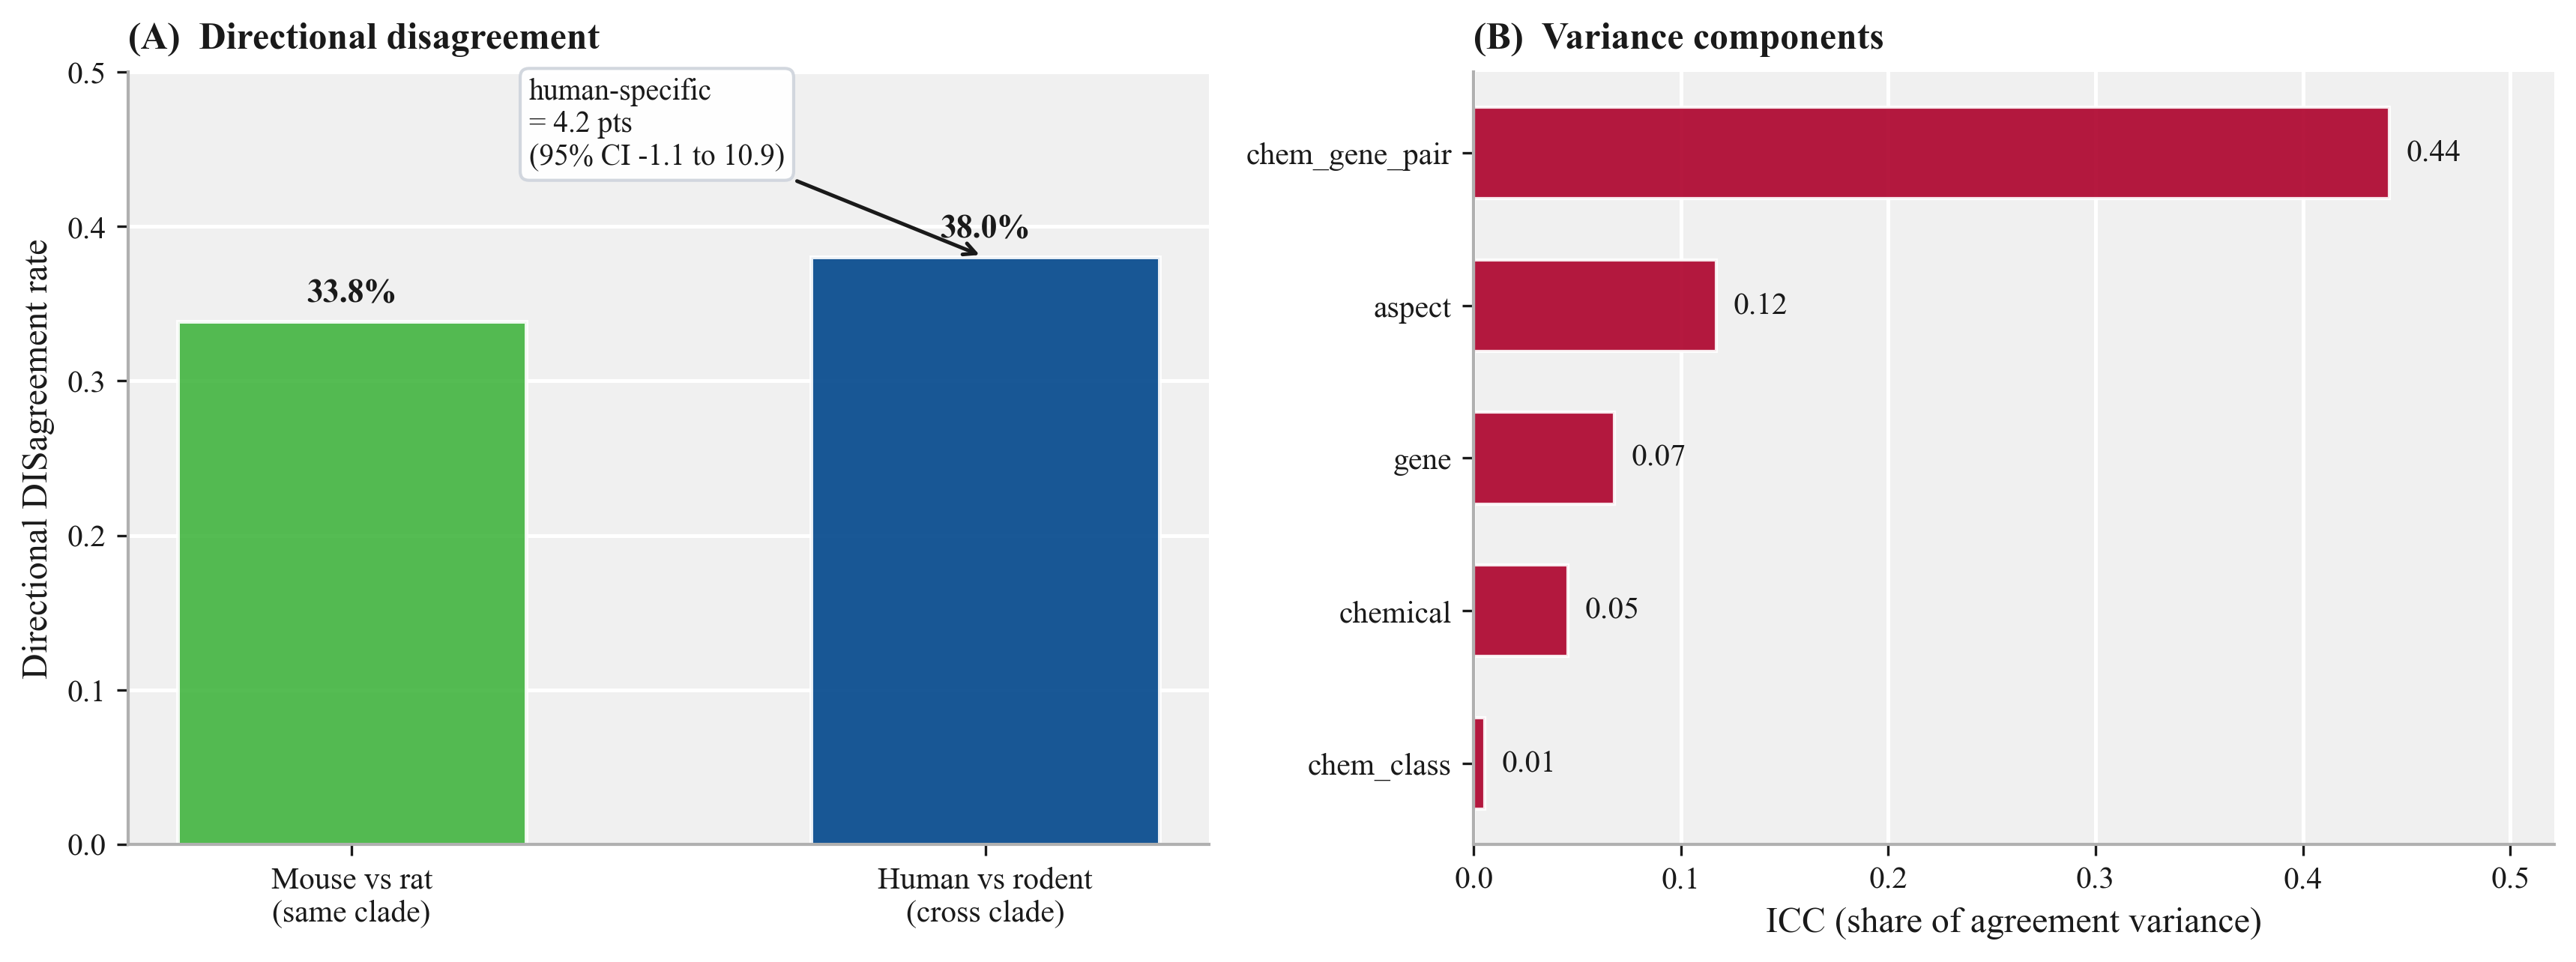

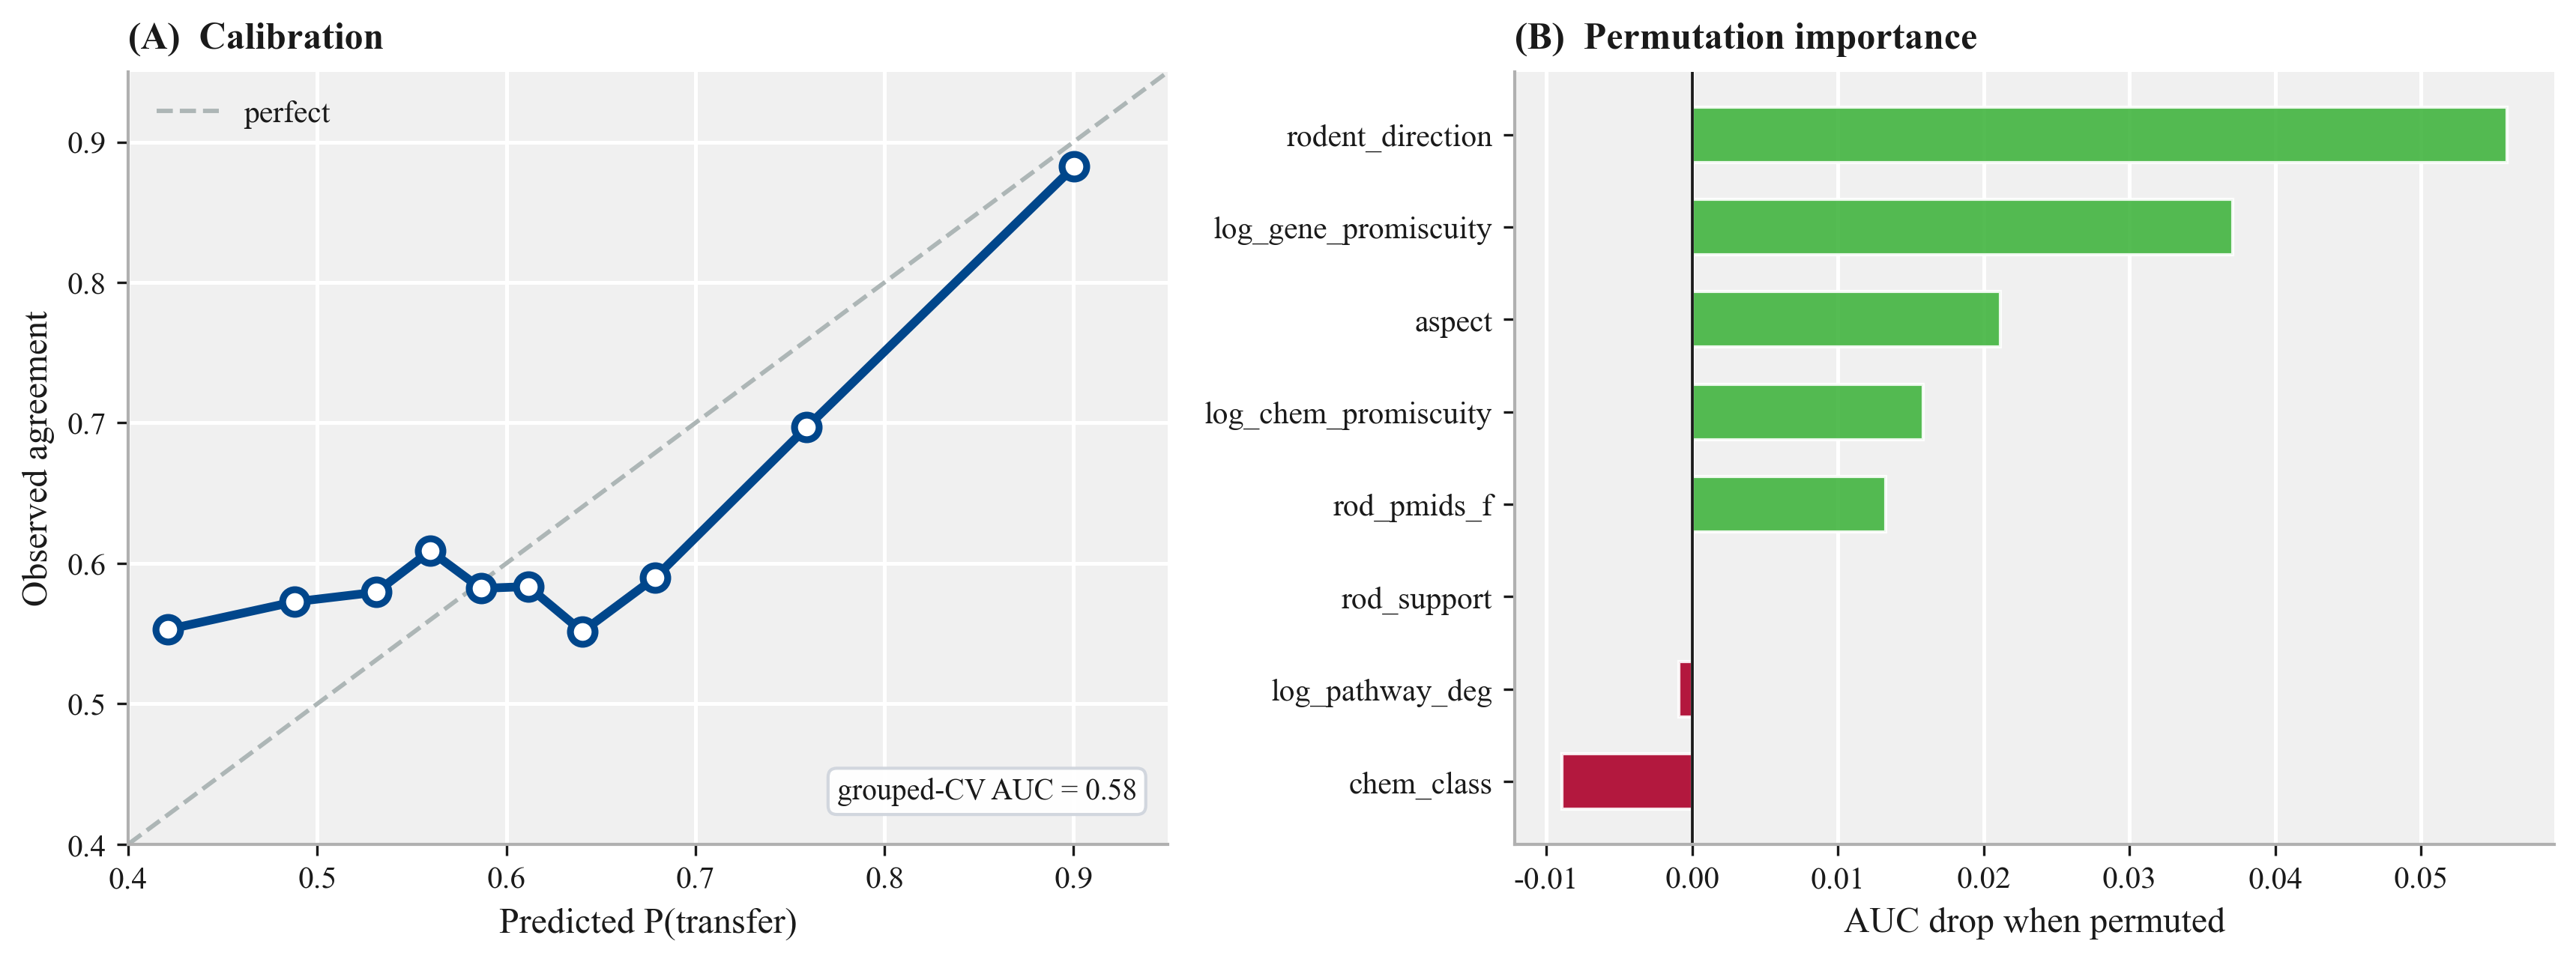

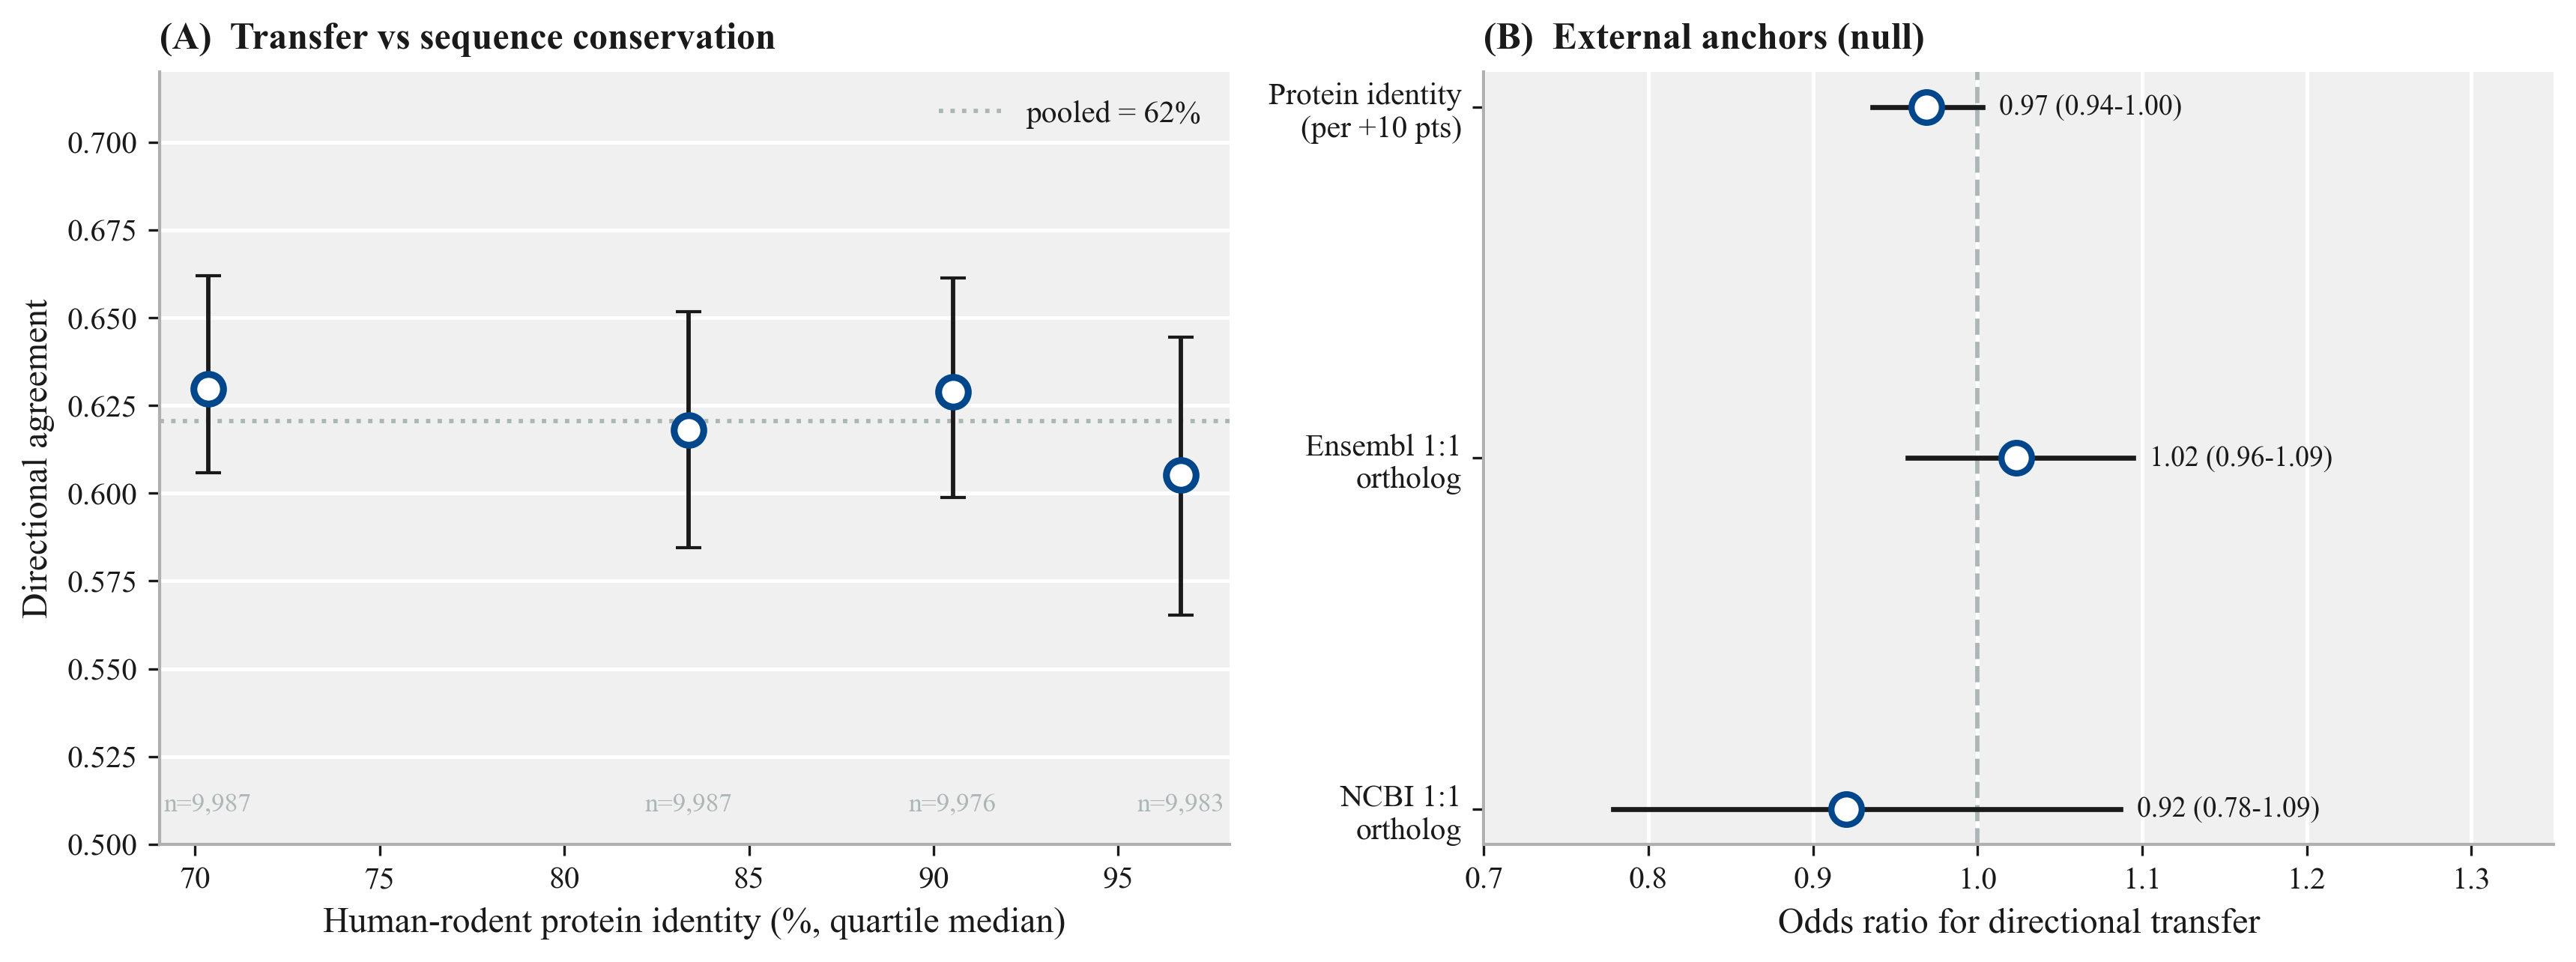

In [8]:
from IPython.display import Image, display
for f in ['F1_overview_agreement','F2_by_aspect','F3_depth','F4_decomposition','F5_prediction','F6_conservation']:
    display(Image(filename=str(cfg.figures / f'{f}.png')))